In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
london = pd.read_csv("london.csv")
stations = pd.read_csv("london_stations.csv")

In [5]:
print(stations.head())
print(stations.columns)

   station_id                          station_name  longitude  latitude
0           1             River Street, Clerkenwell  -0.109971   51.5292
1           2        Phillimore Gardens, Kensington  -0.197574   51.4996
2           3  Christopher Street, Liverpool Street  -0.084606   51.5213
3           4       St. Chad's Street, King's Cross  -0.120974   51.5301
4           5         Sedding Street, Sloane Square  -0.156876   51.4931
Index(['station_id', 'station_name', 'longitude', 'latitude'], dtype='object')


In [6]:
print(london.head())
print(london.columns)

   rental_id  duration  bike_id end_rental_date_time  end_station_id  \
0   61343322      60.0  12871.0  2016-12-28 00:01:00           660.0   
1   61343321     300.0   2837.0  2016-12-28 00:05:00           763.0   
2   61343323     360.0   1269.0  2016-12-28 00:06:00            99.0   
3   61343325    1140.0   4208.0  2016-12-28 00:20:00           468.0   
4   61343324       NaN   1406.0                  NaN             NaN   

                           end_station_name start_rental_date_time  \
0  West Kensington Station, West Kensington    2016-12-28 00:00:00   
1    Mile End Park Leisure Centre, Mile End    2016-12-28 00:00:00   
2             Old Quebec Street, Marylebone    2016-12-28 00:00:00   
3                        Cantrell Road, Bow    2016-12-28 00:01:00   
4                                       NaN    2016-12-28 00:01:00   

   start_station_id                   start_station_name  
0               633  Vereker Road North, West Kensington  
1               531         

In [7]:
london['start_time'] = pd.to_datetime(london['start_rental_date_time'], errors='coerce')
london['end_time']   = pd.to_datetime(london['end_rental_date_time'], errors='coerce')

In [8]:
london = london.dropna(subset=['start_time', 'start_station_id'])

In [9]:
# create hourly bucket
london['hour'] = london['start_time'].dt.floor('H')

C:\Users\rog\AppData\Local\Temp\ipykernel_22724\3538904138.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  london['hour'] = london['start_time'].dt.floor('H')


In [10]:
london.head()

,rental_id,duration,bike_id,end_rental_date_time,end_station_id,end_station_name,start_rental_date_time,start_station_id,start_station_name,start_time,end_time,hour
0,61343322,60.0,12871.0,2016-12-28 00:01:00,660.0,"West Kensington Station, West Kensington",2016-12-28 00:00:00,633,"Vereker Road North, West Kensington",2016-12-28 00:00:00,2016-12-28 00:01:00,2016-12-28
1,61343321,300.0,2837.0,2016-12-28 00:05:00,763.0,"Mile End Park Leisure Centre, Mile End",2016-12-28 00:00:00,531,"Twig Folly Bridge, Mile End",2016-12-28 00:00:00,2016-12-28 00:05:00,2016-12-28
2,61343323,360.0,1269.0,2016-12-28 00:06:00,99.0,"Old Quebec Street, Marylebone",2016-12-28 00:00:00,116,"Little Argyll Street, West End",2016-12-28 00:00:00,2016-12-28 00:06:00,2016-12-28
3,61343325,1140.0,4208.0,2016-12-28 00:20:00,468.0,"Cantrell Road, Bow",2016-12-28 00:01:00,443,"Philpot Street, Whitechapel",2016-12-28 00:01:00,2016-12-28 00:20:00,2016-12-28
4,61343324,NaN,1406.0,NaN,NaN,NaN,2016-12-28 00:01:00,319,"Baldwin Street, St. Luke's",2016-12-28 00:01:00,NaT,2016-12-28


In [11]:
# hourly demand (THIS uses full data)
london_ts = london.groupby('hour').size().rename('count')
london_ts.head()

hour
2016-12-28 00:00:00    102
2016-12-28 01:00:00     75
2016-12-28 02:00:00     30
2016-12-28 03:00:00     28
2016-12-28 04:00:00     32
Name: count, dtype: int64

In [12]:
london_ts.shape

(32250,)

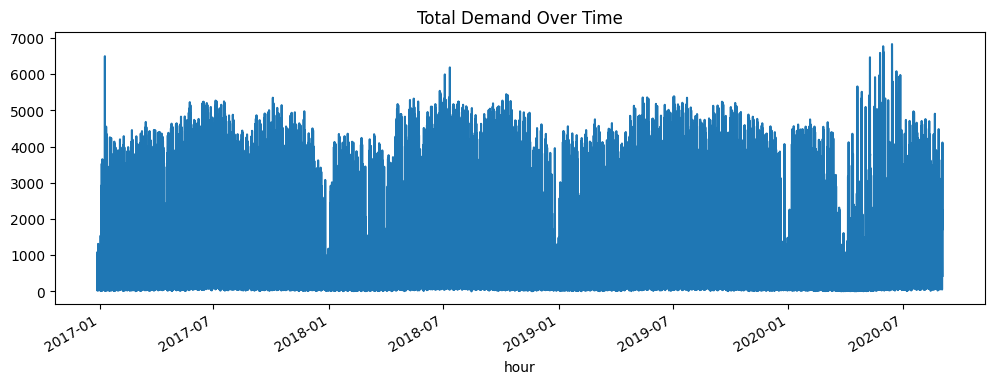

In [13]:
london_ts.plot(figsize=(12,4), title="Total Demand Over Time")
plt.show()

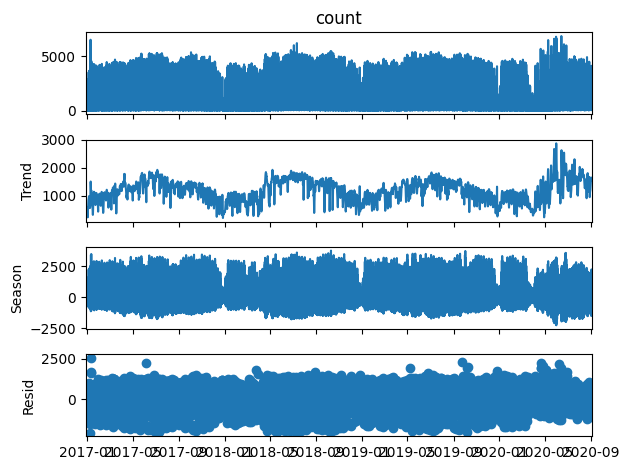

In [14]:
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt

stl = STL(london_ts, period=24)
res = stl.fit()
res.plot()
plt.show()

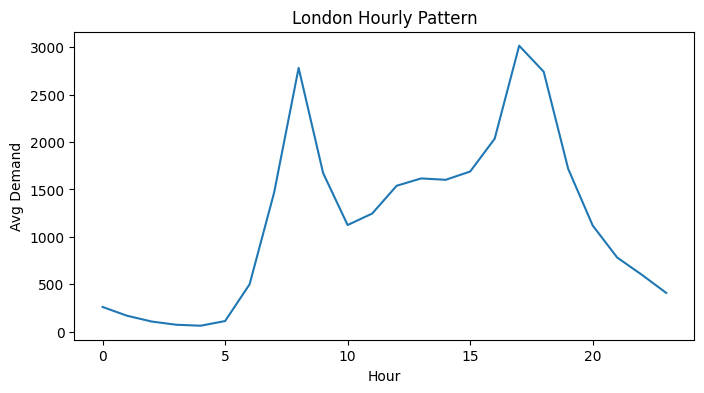

In [15]:
hourly_pattern = london_ts.groupby(london_ts.index.hour).mean()

plt.figure(figsize=(8,4))
plt.plot(hourly_pattern)
plt.title("London Hourly Pattern")
plt.xlabel("Hour")
plt.ylabel("Avg Demand")
plt.show()

<Figure size 1000x400 with 0 Axes>

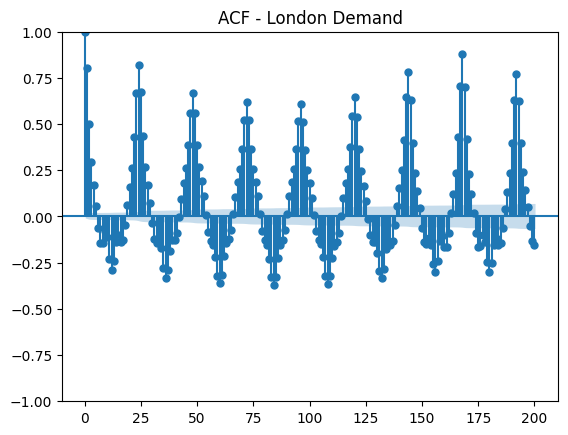

In [16]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plot_acf(london_ts, lags=200)
plt.title("ACF - London Demand")
plt.show()

In [17]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(london_ts)

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value}")

ADF Statistic: -11.743677518658307
p-value: 1.25617083392079e-21
Critical Values:
   1%: -3.430553112659586
   5%: -2.8616297705303895
   10%: -2.566817782074708


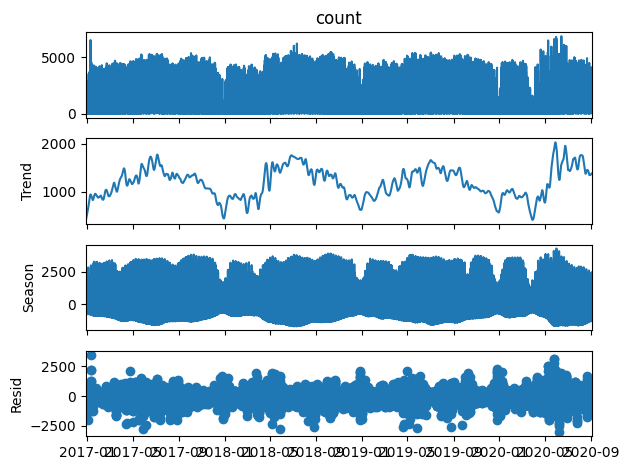

In [18]:
stl_week = STL(london_ts, period=168)
res_week = stl_week.fit()
res_week.plot()
plt.show()

In [19]:
ts = london_ts.to_frame()

# features
ts['lag_1'] = ts['count'].shift(1)
ts['lag_24'] = ts['count'].shift(24)
ts['lag_168'] = ts['count'].shift(168)

ts['hour'] = ts.index.hour
ts['dayofweek'] = ts.index.dayofweek
ts['is_weekend'] = (ts['dayofweek'] >= 5).astype(int)

ts = ts.dropna()


<Axes: xlabel='dayofweek'>

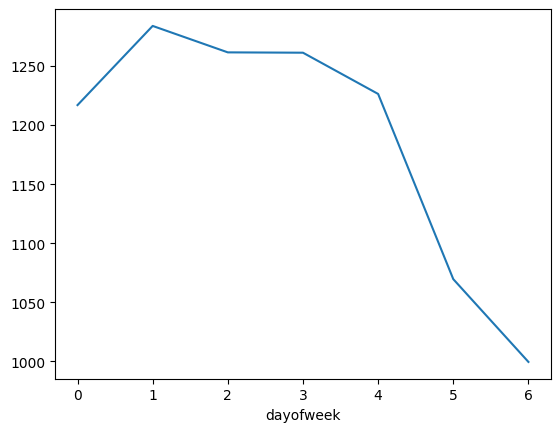

In [20]:
ts['dayofweek'] = ts.index.dayofweek
ts.groupby('dayofweek')['count'].mean().plot()

In [21]:
# split
from sklearn.model_selection import train_test_split
X = ts.drop(columns=['count'])
y = ts['count']

X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False)

In [22]:
ts

,count,lag_1,lag_24,lag_168,hour,dayofweek,is_weekend
hour,,,,,,,
2017-01-04 00:00:00,72,140.0,67.0,102.0,0,2,0
2017-01-04 01:00:00,44,72.0,50.0,75.0,1,2,0
2017-01-04 02:00:00,42,44.0,43.0,30.0,2,2,0
2017-01-04 03:00:00,20,42.0,10.0,28.0,3,2,0
2017-01-04 04:00:00,41,20.0,30.0,32.0,4,2,0
...,...,...,...,...,...,...,...
2020-09-01 19:00:00,3030,4112.0,2678.0,1862.0,19,1,0
2020-09-01 20:00:00,1925,3030.0,1947.0,1178.0,20,1,0
2020-09-01 21:00:00,1114,1925.0,1444.0,1006.0,21,1,0


In [23]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

pred_lin = model.predict(X_test)
from sklearn.metrics import mean_squared_error

print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_lin)))

RMSE: 456.8599541528932


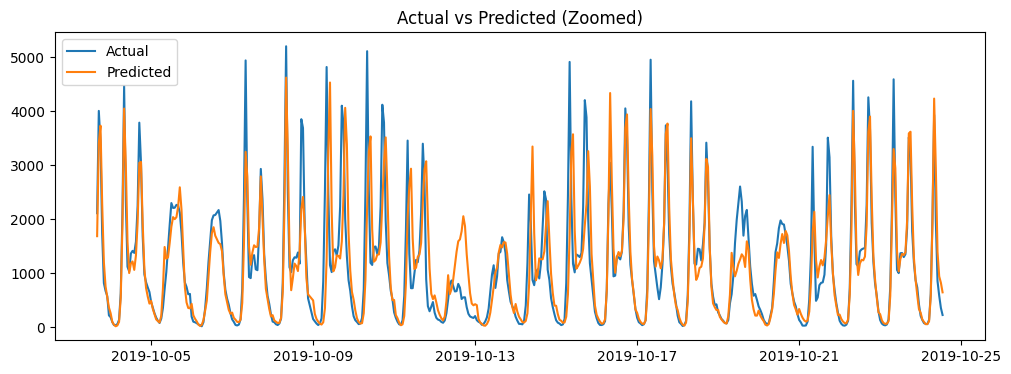

In [25]:
plt.figure(figsize=(12,4))

plt.plot(y_test.index[:500], y_test[:500], label='Actual')
plt.plot(y_test.index[:500], pred_lin[:500], label='Predicted')

plt.title("Actual vs Predicted (Zoomed)")
plt.legend()
plt.show()

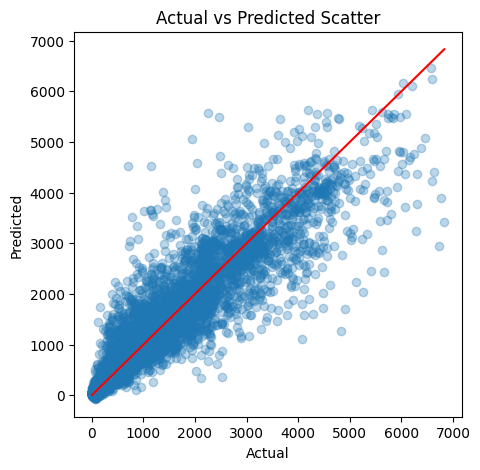

In [26]:
plt.figure(figsize=(5,5))

plt.scatter(y_test, pred_lin, alpha=0.3)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Scatter")

# perfect line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.show()

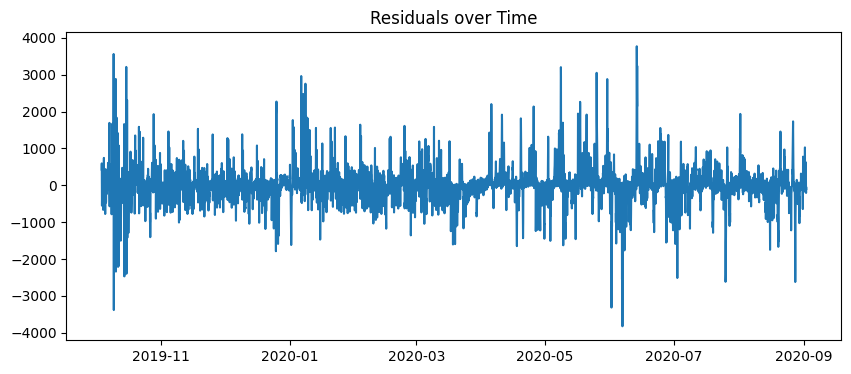

In [27]:
residuals = y_test - pred_lin

plt.figure(figsize=(10,4))
plt.plot(y_test.index, residuals)
plt.title("Residuals over Time")
plt.show()

In [28]:
# model
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred_rf))
print("RMSE:", rmse)

RMSE: 349.280496372441


In [29]:
from xgboost import XGBRegressor

model = XGBRegressor(n_estimators=100, learning_rate=0.1)
model.fit(X_train, y_train)
pred_xg = model.predict(X_test)

In [30]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, pred_xg))
print("RMSE:", rmse)

RMSE: 301.3263314803577


<h1>feature engineering

In [31]:
ts['rolling_mean_24'] = ts['count'].rolling(24).mean()
ts['rolling_std_24'] = ts['count'].rolling(24).std()
ts['log_count'] = np.log1p(ts['count'])
ts['is_morning_peak'] = ts.index.hour.isin([7,8,9]).astype(int)
ts['is_evening_peak'] = ts.index.hour.isin([16,17,18]).astype(int)
ts['lag24_x_peak'] = ts['lag_24'] * ts['is_evening_peak']
ts['is_weekday'] = (ts.index.dayofweek < 5).astype(int)
ts = ts.dropna()

In [32]:
ts

,count,lag_1,lag_24,lag_168,hour,dayofweek,is_weekend,rolling_mean_24,rolling_std_24,log_count,is_morning_peak,is_evening_peak,lag24_x_peak,is_weekday
hour,,,,,,,,,,,,,,
2017-01-04 23:00:00,172,329.0,140.0,198.0,23,2,0,922.666667,967.203394,5.153292,0,0,0.0,1
2017-01-05 00:00:00,86,172.0,72.0,136.0,0,3,0,923.250000,966.672115,4.465908,0,0,0.0,1
2017-01-05 01:00:00,66,86.0,44.0,80.0,1,3,0,924.166667,965.812146,4.204693,0,0,0.0,1
2017-01-05 02:00:00,38,66.0,42.0,52.0,2,3,0,924.000000,965.971329,3.663562,0,0,0.0,1
2017-01-05 03:00:00,23,38.0,20.0,62.0,3,3,0,924.125000,965.849449,3.178054,0,0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-09-01 19:00:00,3030,4112.0,2678.0,1862.0,19,1,0,1525.458333,1170.411633,8.016648,0,0,0.0,1
2020-09-01 20:00:00,1925,3030.0,1947.0,1178.0,20,1,0,1524.541667,1170.075694,7.563201,0,0,0.0,1
2020-09-01 21:00:00,1114,1925.0,1444.0,1006.0,21,1,0,1510.791667,1172.998646,7.016610,0,0,0.0,1


In [33]:
# split
from sklearn.model_selection import train_test_split
X = ts.drop(columns=['count', 'log_count'])
y = ts['log_count']

X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False)

In [34]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

pred_lin_log = model.predict(X_test)
y_pred = np.expm1(pred_lin_log)
y_true = np.expm1(y_test)

In [35]:
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print(rmse)

4239.173787255575


In [36]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)

pred_log = model.predict(X_test)
y_test_actual = np.expm1(y_test)
pred_actual = np.expm1(pred_log)

In [37]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test_actual, pred_actual))
print("RMSE:", rmse)

RMSE: 341.81930741781287


In [38]:
from xgboost import XGBRegressor

model = XGBRegressor(n_estimators=100, learning_rate=0.1)
model.fit(X_train, y_train)
pred_log = model.predict(X_test)

In [39]:
y_test_actual = np.expm1(y_test)
pred_actual = np.expm1(pred_log)

In [40]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test_actual, pred_actual))
print("RMSE:", rmse)

RMSE: 304.15008958893947


In [41]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
import numpy as np

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred_log = ridge.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

In [42]:
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print("Ridge RMSE:", rmse)

Ridge RMSE: 4239.0623754320695


<h1>Spatial

In [43]:
station_avg = (
    london.groupby('start_station_id')
    .size()
    .reset_index(name='total_trips')
)

# average per hour (optional)
station_avg['avg_demand'] = station_avg['total_trips'] / london_ts.shape[0]

In [44]:
london_spatial = pd.merge(
    station_avg,
    stations,
    left_on='start_station_id',
    right_on='station_id'
)

london_spatial = london_spatial.dropna(subset=['longitude','latitude'])

In [45]:
london_spatial.head()

,start_station_id,total_trips,avg_demand,station_id,station_name,longitude,latitude
0,1,30013,0.930636,1,"River Street, Clerkenwell",-0.109971,51.5292
1,2,59675,1.850388,2,"Phillimore Gardens, Kensington",-0.197574,51.4996
2,3,54389,1.686481,3,"Christopher Street, Liverpool Street",-0.084606,51.5213
3,4,31251,0.969023,4,"St. Chad's Street, King's Cross",-0.120974,51.5301
4,5,75582,2.343628,5,"Sedding Street, Sloane Square",-0.156876,51.4931


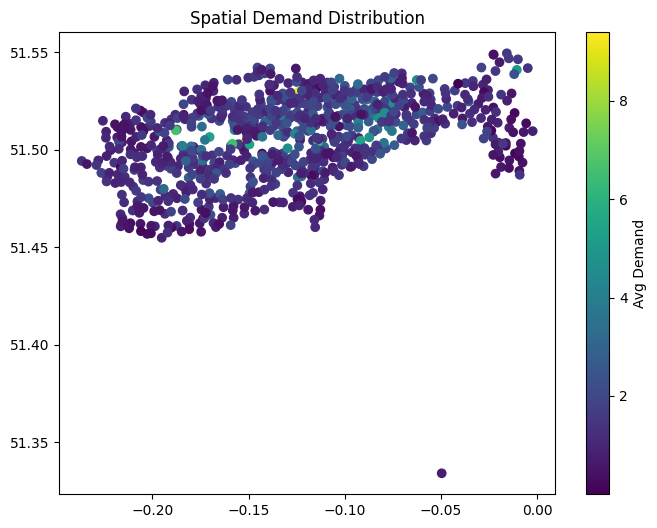

In [46]:
plt.figure(figsize=(8,6))
plt.scatter(london_spatial['longitude'], london_spatial['latitude'],
            c=london_spatial['avg_demand'], cmap='viridis')
plt.colorbar(label='Avg Demand')
plt.title("Spatial Demand Distribution")
plt.show()

In [47]:
import libpysal
from esda.moran import Moran

coords = london_spatial[['longitude','latitude']].values

w = libpysal.weights.KNN.from_array(coords, k=5)
w.transform = 'r'

moran = Moran(london_spatial['avg_demand'], w)

print("Moran's I:", moran.I)
print("p-value:", moran.p_sim)

Moran's I: 0.23584621430807162
p-value: 0.001


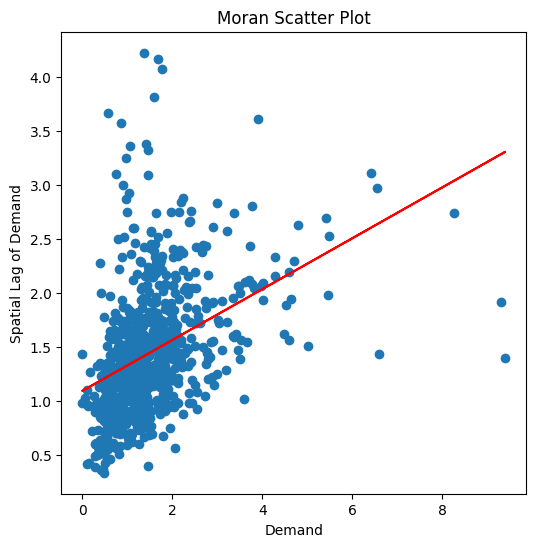

In [48]:
import matplotlib.pyplot as plt
import numpy as np

# spatial lag
w = w  # your weights from earlier
y = london_spatial['avg_demand'].values

# compute spatial lag
lag_y = libpysal.weights.spatial_lag.lag_spatial(w, y)

plt.figure(figsize=(6,6))
plt.scatter(y, lag_y)

# regression line
b, a = np.polyfit(y, lag_y, 1)
plt.plot(y, a + b*y, color='red')

plt.xlabel("Demand")
plt.ylabel("Spatial Lag of Demand")
plt.title("Moran Scatter Plot")
plt.show()

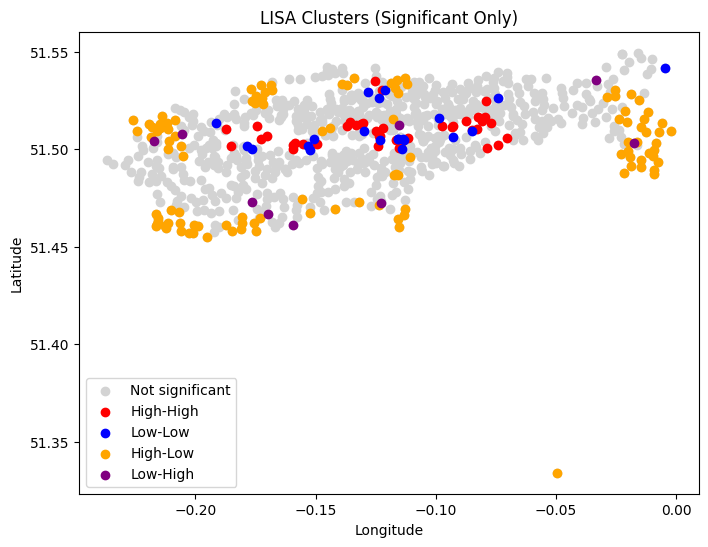

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import libpysal
from esda.moran import Moran_Local

# -------------------------------
# 1. Prepare spatial weights
# -------------------------------
coords = london_spatial[['longitude','latitude']].values

w = libpysal.weights.KNN.from_array(coords, k=5)
w.transform = 'r'

# -------------------------------
# 2. (Optional but better) Standardize demand
# -------------------------------
y = (london_spatial['avg_demand'] - london_spatial['avg_demand'].mean()) / london_spatial['avg_demand'].std()

# -------------------------------
# 3. Compute LISA
# -------------------------------
lisa = Moran_Local(y, w)

london_spatial['lisa_cluster'] = lisa.q
london_spatial['p'] = lisa.p_sim

# -------------------------------
# 4. Map cluster labels
# -------------------------------
cluster_labels = {
    1: 'High-High',
    2: 'Low-Low',
    3: 'High-Low',
    4: 'Low-High'
}

london_spatial['lisa_label'] = london_spatial['lisa_cluster'].map(cluster_labels)

# -------------------------------
# 5. Filter significant points
# -------------------------------
sig = london_spatial[london_spatial['p'] < 0.05]

# -------------------------------
# 6. Plot LISA clusters
# -------------------------------
plt.figure(figsize=(8,6))

# base map (non-significant)
plt.scatter(london_spatial['longitude'],
            london_spatial['latitude'],
            color='lightgrey',
            label='Not significant')

# colors for clusters
colors = {
    1: 'red',      # High-High
    2: 'blue',     # Low-Low
    3: 'orange',   # High-Low
    4: 'purple'    # Low-High
}

labels = {
    1: 'High-High',
    2: 'Low-Low',
    3: 'High-Low',
    4: 'Low-High'
}

# plot each cluster separately
for cluster in [1,2,3,4]:
    subset = sig[sig['lisa_cluster'] == cluster]
    plt.scatter(subset['longitude'],
                subset['latitude'],
                c=colors[cluster],
                label=labels[cluster])

plt.legend()
plt.title("LISA Clusters (Significant Only)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [50]:
center_lon = london_spatial['longitude'].mean()
center_lat = london_spatial['latitude'].mean()

In [51]:
london_spatial['dist_center'] = np.sqrt(
    (london_spatial['longitude'] - center_lon)**2 +
    (london_spatial['latitude'] - center_lat)**2
)

In [52]:
from sklearn.neighbors import NearestNeighbors

coords = london_spatial[['longitude','latitude']].values
nbrs = NearestNeighbors(n_neighbors=5).fit(coords)
_, indices = nbrs.kneighbors(coords)

neighbor_vals = []
for i, neigh in enumerate(indices):
    neighbor_vals.append(london_spatial.iloc[neigh]['avg_demand'].mean())

london_spatial['neighbor_demand'] = neighbor_vals

In [53]:
london_spatial

,start_station_id,total_trips,avg_demand,station_id,station_name,longitude,latitude,lisa_cluster,p,lisa_label,dist_center,neighbor_demand
0,1,30013,0.930636,1,"River Street, Clerkenwell",-0.109971,51.529200,3,0.478,High-Low,0.029717,1.247634
1,2,59675,1.850388,2,"Phillimore Gardens, Kensington",-0.197574,51.499600,4,0.235,Low-High,0.069668,1.091305
2,3,54389,1.686481,3,"Christopher Street, Liverpool Street",-0.084606,51.521300,1,0.205,High-High,0.046274,1.829098
3,4,31251,0.969023,4,"St. Chad's Street, King's Cross",-0.120974,51.530100,2,0.011,Low-Low,0.025429,2.850195
4,5,75582,2.343628,5,"Sedding Street, Sloane Square",-0.156876,51.493100,4,0.425,Low-High,0.031350,1.478505
...,...,...,...,...,...,...,...,...,...,...,...,...
796,834,22265,0.690388,834,"Gas Holders, Battersea Park",-0.147857,51.477966,3,0.438,High-Low,0.034018,1.372955
797,835,15340,0.475659,835,"Farringdon Street, Holborn",-0.104948,51.516785,2,0.207,Low-Low,0.025731,1.499522
798,836,18649,0.578264,836,"York Way, Kings Cross",-0.125442,51.541596,3,0.402,High-Low,0.035988,1.170871
799,838,13645,0.423101,838,"Fore Street Avenue, Guildhall",-0.091402,51.518093,3,0.461,High-Low,0.038801,0.981222


In [54]:
X = london_spatial[['longitude','latitude','dist_center','neighbor_demand']]
y = london_spatial['avg_demand']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

pred = rf.predict(X_test)

from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(y_test, pred))
print("Spatial RMSE:", rmse)

Spatial RMSE: 0.7915392420016722


In [55]:
from sklearn.preprocessing import StandardScaler

# base features
X_geo = london_spatial[['longitude','latitude']]
X_demand = london_spatial[['avg_demand','neighbor_demand']]

# combined
X_scaled = london_spatial[['longitude','latitude','avg_demand','neighbor_demand']]

# scale combined (important)
scaler = StandardScaler()
X_scaled_norm = scaler.fit_transform(X_scaled)

In [56]:
from sklearn.cluster import KMeans

k = 4

# 1. GEO clustering
kmeans_geo = KMeans(n_clusters=k, random_state=42)
london_spatial['cluster_geo'] = kmeans_geo.fit_predict(X_geo)

# 2. DEMAND clustering
kmeans_demand = KMeans(n_clusters=k, random_state=42)
london_spatial['cluster_demand'] = kmeans_demand.fit_predict(X_demand)

# 3. SCALED (geo + demand)
kmeans_scaled = KMeans(n_clusters=k, random_state=42)
london_spatial['cluster_scaled'] = kmeans_scaled.fit_predict(X_scaled_norm)

In [57]:
print("\nScaled clustering:")
print(london_spatial.groupby('cluster_scaled')['avg_demand'].mean())

print("\nGeo clustering:")
print(london_spatial.groupby('cluster_geo')['avg_demand'].mean())

print("\nDemand clustering:")
print(london_spatial.groupby('cluster_demand')['avg_demand'].mean())


Scaled clustering:
cluster_scaled
0    2.019639
1    1.097132
2    1.054453
3    5.012778
Name: avg_demand, dtype: float64

Geo clustering:
cluster_geo
0    1.195833
1    1.589822
2    1.742535
3    1.216513
Name: avg_demand, dtype: float64

Demand clustering:
cluster_demand
0    2.619976
1    0.769274
2    5.630775
3    1.489923
Name: avg_demand, dtype: float64


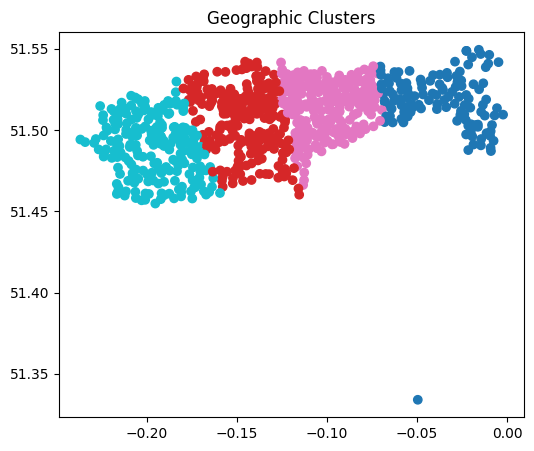

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.scatter(london_spatial['longitude'],
            london_spatial['latitude'],
            c=london_spatial['cluster_geo'],
            cmap='tab10')
plt.title("Geographic Clusters")
plt.show()

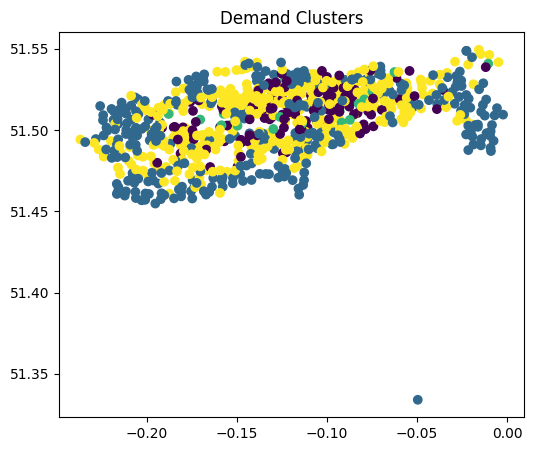

In [59]:
plt.figure(figsize=(6,5))
plt.scatter(london_spatial['longitude'],
            london_spatial['latitude'],
            c=london_spatial['cluster_demand'],
            cmap='viridis')
plt.title("Demand Clusters")
plt.show()

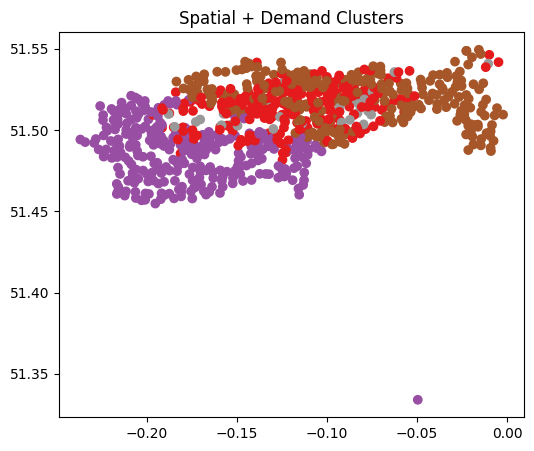

In [60]:
plt.figure(figsize=(6,5))
plt.scatter(london_spatial['longitude'],
            london_spatial['latitude'],
            c=london_spatial['cluster_scaled'],
            cmap='Set1')
plt.title("Spatial + Demand Clusters")
plt.show()

<h1>OD Matrix

In [61]:
od = london.groupby(['start_station_id','end_station_id']).size().reset_index(name='count')
od.head()

,start_station_id,end_station_id,count
0,1,1.0,1316
1,1,2.0,2
2,1,3.0,58
3,1,4.0,58
4,1,5.0,1


In [62]:
od_matrix = od.pivot(index='start_station_id',
                     columns='end_station_id',
                     values='count').fillna(0)

print(od_matrix.shape)

(807, 808)


In [63]:
# top 10 OD flows
top_flows = od.sort_values('count', ascending=False).head(10)
print(top_flows)

        start_station_id  end_station_id  count
129908               191           191.0  72625
479806               785           785.0  67661
205568               303           303.0  42049
207594               307           307.0  40221
167938               248           248.0  35652
75755                111           111.0  35438
481495               789           789.0  23977
271612               404           404.0  20312
143891               213           213.0  16447
129962               191           248.0  15739


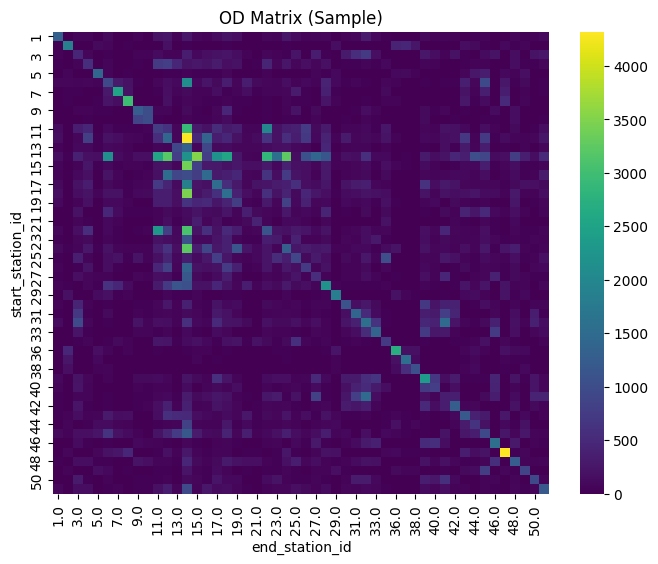

In [64]:
import seaborn as sns

sample = od_matrix.iloc[:50, :50]

plt.figure(figsize=(8,6))
sns.heatmap(sample, cmap='viridis')
plt.title("OD Matrix (Sample)")
plt.show()

In [65]:
# -------------------------------
# 1. Create hour column
# -------------------------------
# -------------------------------
# 1. Fix datetime column
# -------------------------------
london['start_rental_date_time'] = pd.to_datetime(
    london['start_rental_date_time'],
    errors='coerce'
)

# drop broken rows if any
london = london.dropna(subset=['start_rental_date_time'])

# -------------------------------
# 2. Create hour column
# -------------------------------
london['hour'] = london['start_rental_date_time'].dt.floor('H')
london['hour'] = london['start_rental_date_time'].dt.floor('H')

# -------------------------------
# 2. Aggregate demand
# -------------------------------
london_demand = (
    london.groupby(['start_station_id','hour'])
    .size()
    .reset_index(name='count')
    .rename(columns={'start_station_id':'station_id'})
)

# -------------------------------
# 3. Create full grid (station × hour)
# -------------------------------
all_hours = pd.date_range(
    london_demand['hour'].min(),
    london_demand['hour'].max(),
    freq='H'
)

all_stations = london_demand['station_id'].unique()

full_index = pd.MultiIndex.from_product(
    [all_stations, all_hours],
    names=['station_id','hour']
)

full_df = pd.DataFrame(index=full_index).reset_index()

# -------------------------------
# 4. Merge + fill missing
# -------------------------------
london_complete = pd.merge(
    full_df,
    london_demand,
    on=['station_id','hour'],
    how='left'
)

london_complete['count'] = london_complete['count'].fillna(0)

# -------------------------------
# 5. (Optional) merge coordinates
# -------------------------------
london_complete = pd.merge(
    london_complete,
    stations,
    on='station_id',
    how='left'
)

print(london_complete.head())
print(london_complete.shape)

C:\Users\rog\AppData\Local\Temp\ipykernel_22724\164220751.py:18: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  london['hour'] = london['start_rental_date_time'].dt.floor('H')
C:\Users\rog\AppData\Local\Temp\ipykernel_22724\164220751.py:19: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  london['hour'] = london['start_rental_date_time'].dt.floor('H')
C:\Users\rog\AppData\Local\Temp\ipykernel_22724\164220751.py:34: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  all_hours = pd.date_range(


   station_id                hour  count               station_name  \
0           1 2016-12-28 00:00:00    0.0  River Street, Clerkenwell   
1           1 2016-12-28 01:00:00    0.0  River Street, Clerkenwell   
2           1 2016-12-28 02:00:00    0.0  River Street, Clerkenwell   
3           1 2016-12-28 03:00:00    0.0  River Street, Clerkenwell   
4           1 2016-12-28 04:00:00    0.0  River Street, Clerkenwell   

   longitude  latitude  
0  -0.109971   51.5292  
1  -0.109971   51.5292  
2  -0.109971   51.5292  
3  -0.109971   51.5292  
4  -0.109971   51.5292  
(26030592, 6)


In [66]:
# =============================
# Station hourly profile (0–23)
# =============================
station_hour = london_complete.copy()

station_hour['hour_only'] = station_hour['hour'].dt.hour

profile = (
    station_hour.groupby(['station_id', 'hour_only'])['count']
    .mean()
    .unstack()
    .fillna(0)
)

print(profile.shape)  # (stations, 24)

(807, 24)


In [67]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
profile_scaled = scaler.fit_transform(profile)

In [68]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
profile['cluster_behavior'] = kmeans.fit_predict(profile_scaled)

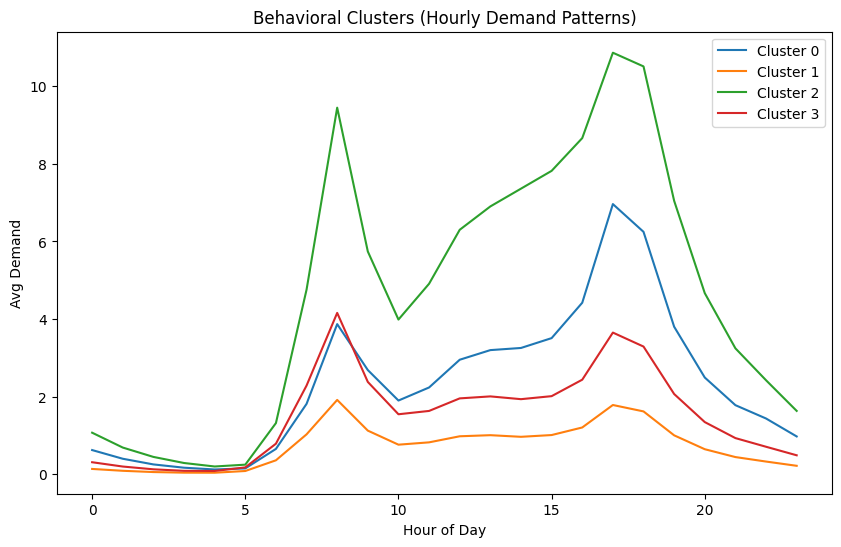

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for c in range(4):
    cluster_data = profile[profile['cluster_behavior'] == c].drop(columns=['cluster_behavior'])
    mean_pattern = cluster_data.mean()
    plt.plot(mean_pattern, label=f'Cluster {c}')

plt.title("Behavioral Clusters (Hourly Demand Patterns)")
plt.xlabel("Hour of Day")
plt.ylabel("Avg Demand")
plt.legend()
plt.show()

In [70]:
profile = profile.reset_index()

london_behavior = pd.merge(profile, stations, on='station_id')

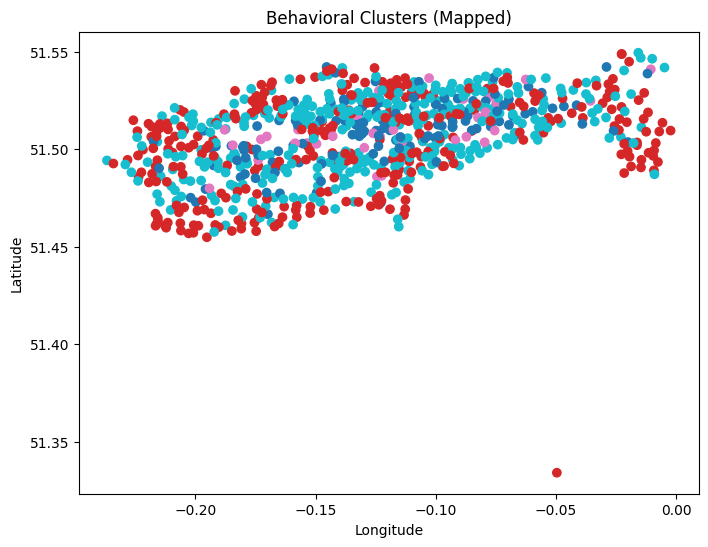

In [71]:
plt.figure(figsize=(8,6))

plt.scatter(london_behavior['longitude'],
            london_behavior['latitude'],
            c=london_behavior['cluster_behavior'],
            cmap='tab10')

plt.title("Behavioral Clusters (Mapped)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [72]:
pd.crosstab(london_spatial['cluster_geo'],
            london_behavior['cluster_behavior'])

cluster_behavior,0,1,2,3
cluster_geo,,,,
0,16,60,3,46
1,41,80,13,97
2,48,73,13,107
3,23,98,4,79


In [73]:
threshold = london_spatial['avg_demand'].quantile(0.75)

london_spatial['is_high'] = (london_spatial['avg_demand'] >= threshold).astype(int)

In [74]:
from sklearn.neighbors import NearestNeighbors

coords = london_spatial[['longitude', 'latitude']].values

nbrs = NearestNeighbors(n_neighbors=5).fit(coords)
distances, indices = nbrs.kneighbors(coords)

In [75]:
high_ratios = []

for i, neigh in enumerate(indices):
    neighbor_vals = london_spatial.iloc[neigh]['is_high']
    high_ratios.append(neighbor_vals.mean())

london_spatial['neighbor_high_ratio'] = high_ratios

In [76]:
print(london_spatial[['avg_demand', 'neighbor_high_ratio']].corr())

                     avg_demand  neighbor_high_ratio
avg_demand             1.000000             0.509237
neighbor_high_ratio    0.509237             1.000000


In [77]:
# merge behavior + spatial demand
combined = pd.merge(london_behavior,
                    london_spatial[['station_id', 'avg_demand']],
                    on='station_id')

# compare average demand per behavior cluster
print(combined.groupby('cluster_behavior')['avg_demand'].mean())

cluster_behavior
0    2.329440
1    0.749215
2    4.606607
3    1.524788
Name: avg_demand, dtype: float64


<Figure size 1000x400 with 0 Axes>

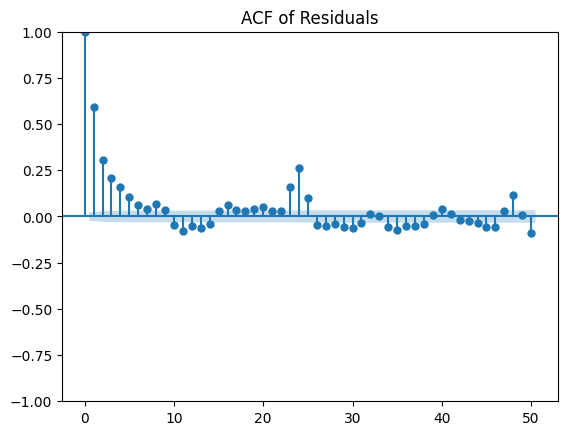

In [78]:
from statsmodels.graphics.tsaplots import plot_acf

residuals = y_test_actual - pred_actual

plt.figure(figsize=(10,4))
plot_acf(residuals, lags=50)
plt.title("ACF of Residuals")
plt.show()

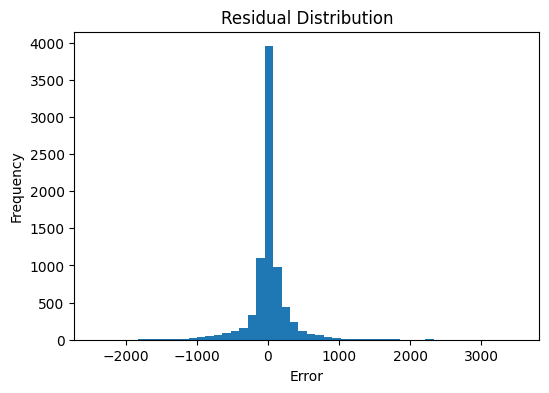

In [79]:
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=50)
plt.title("Residual Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

In [80]:
# =============================
# Colocation (neighbor similarity)
# =============================
from sklearn.neighbors import NearestNeighbors

# define high-demand stations
threshold = london_spatial['avg_demand'].quantile(0.75)
london_spatial['is_high'] = (london_spatial['avg_demand'] >= threshold).astype(int)

coords = london_spatial[['longitude', 'latitude']].values

nbrs = NearestNeighbors(n_neighbors=5).fit(coords)
_, indices = nbrs.kneighbors(coords)

high_ratios = []
for i, neigh in enumerate(indices):
    neighbor_vals = london_spatial.iloc[neigh]['is_high']
    high_ratios.append(neighbor_vals.mean())

london_spatial['neighbor_high_ratio'] = high_ratios

# correlation
print("Colocation correlation:",
      london_spatial[['avg_demand', 'neighbor_high_ratio']].corr())

Colocation correlation:                      avg_demand  neighbor_high_ratio
avg_demand             1.000000             0.509237
neighbor_high_ratio    0.509237             1.000000


In [81]:
import numpy as np

# basic features
london_spatial['lon'] = london_spatial['longitude']
london_spatial['lat'] = london_spatial['latitude']

# already computed:
# avg_demand
# neighbor_high_ratio

# OPTIONAL: distance from city center (very useful)
center_lon = london_spatial['longitude'].mean()
center_lat = london_spatial['latitude'].mean()

london_spatial['dist_center'] = np.sqrt(
    (london_spatial['longitude'] - center_lon)**2 +
    (london_spatial['latitude'] - center_lat)**2
)

In [82]:
london_spatial.head()

,start_station_id,total_trips,avg_demand,station_id,station_name,longitude,latitude,lisa_cluster,p,lisa_label,dist_center,neighbor_demand,cluster_geo,cluster_demand,cluster_scaled,is_high,neighbor_high_ratio,lon,lat
0,1,30013,0.930636,1,"River Street, Clerkenwell",-0.109971,51.5292,3,0.478,High-Low,0.029717,1.247634,2,1,2,0,0.2,-0.109971,51.5292
1,2,59675,1.850388,2,"Phillimore Gardens, Kensington",-0.197574,51.4996,4,0.235,Low-High,0.069668,1.091305,3,3,1,1,0.2,-0.197574,51.4996
2,3,54389,1.686481,3,"Christopher Street, Liverpool Street",-0.084606,51.5213,1,0.205,High-High,0.046274,1.829098,2,3,0,0,0.4,-0.084606,51.5213
3,4,31251,0.969023,4,"St. Chad's Street, King's Cross",-0.120974,51.5301,2,0.011,Low-Low,0.025429,2.850195,2,3,0,0,0.4,-0.120974,51.5301
4,5,75582,2.343628,5,"Sedding Street, Sloane Square",-0.156876,51.4931,4,0.425,Low-High,0.031350,1.478505,1,0,1,1,0.4,-0.156876,51.4931


In [83]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

X = london_spatial[
    ['longitude', 'latitude', 'dist_center', 'neighbor_demand']
]
y = london_spatial['avg_demand']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [84]:
lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
print("Linear RMSE:", rmse_lr)

Linear RMSE: 0.703948088577215


In [85]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
print("RF RMSE:", rmse_rf)

RF RMSE: 0.8122652822139287


In [86]:
from xgboost import XGBRegressor

model = XGBRegressor(n_estimators=100, learning_rate=0.1)
model.fit(X_train, y_train)
pred_xgb = model.predict(X_test)


rmse_xgb = np.sqrt(mean_squared_error(y_test, pred_xgb))
print("xgb RMSE:", rmse_xgb)

xgb RMSE: 0.8297228056409482


In [87]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
pred = ridge.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred))
print("Ridge RMSE:", rmse)

Ridge RMSE: 0.7006735676447285


In [88]:
import pandas as pd

importance = pd.Series(rf.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False))

neighbor_demand    0.603266
latitude           0.169683
longitude          0.118697
dist_center        0.108354
dtype: float64


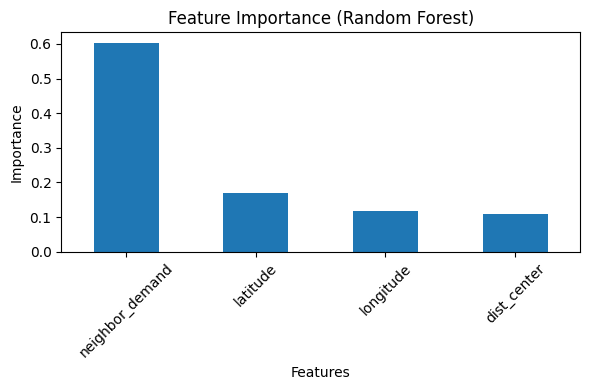

In [89]:
import pandas as pd
import matplotlib.pyplot as plt

# extract importance
feat_imp = pd.Series(rf.feature_importances_, index=X.columns)

# sort
feat_imp = feat_imp.sort_values(ascending=False)

# plot
plt.figure(figsize=(6,4))
feat_imp.plot(kind='bar')

plt.title("Feature Importance (Random Forest)")
plt.ylabel("Importance")
plt.xlabel("Features")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [90]:
print(type(london_ts))

<class 'pandas.core.series.Series'>


In [91]:
# =============================
# Normalize series
# =============================
ts = london_ts.copy()

ts_norm = (ts - ts.mean()) / ts.std()

# convert to DataFrame
ts_df = ts_norm.to_frame(name='norm')

In [92]:
# =============================
# Symbol encoding
# =============================
def to_symbol(x):
    if x < -0.5:
        return 'L'   # low
    elif x < 0.5:
        return 'M'   # medium
    else:
        return 'H'   # high

ts_df['symbol'] = ts_df['norm'].apply(to_symbol)


In [93]:
# =============================
# Time features
# =============================
ts_df['date'] = ts_df.index.date
ts_df['hour'] = ts_df.index.hour

In [94]:
# =============================
# Daily sequences
# =============================
daily_seq = ts_df.groupby('date')['symbol'].apply(list)

print("Example sequence:")
print(daily_seq.iloc[0])

Example sequence:
['L', 'L', 'L', 'L', 'L', 'L', 'L', 'L', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'L', 'L', 'L', 'L', 'L']


In [95]:
# =============================
# Sequence mining
# =============================
from collections import Counter

def get_subseq(seq, k=3):
    return [''.join(seq[i:i+k]) for i in range(len(seq)-k+1)]

patterns = Counter()

for seq in daily_seq:
    subseqs = get_subseq(seq, k=3)
    patterns.update(subseqs)

# Top patterns
top_patterns = patterns.most_common(10)

print("\nTop 10 patterns:")
for p in top_patterns:
    print(p)


Top 10 patterns:
('LLL', 8150)
('MMM', 5356)
('HHH', 3985)
('HHM', 1866)
('HMM', 1858)
('MHH', 1809)
('LLM', 1363)
('MML', 1144)
('MMH', 1141)
('MLL', 917)


In [96]:
# =============================
# Try length 4
# =============================
patterns_4 = Counter()

for seq in daily_seq:
    patterns_4.update(get_subseq(seq, k=4))

print("\nTop length-4 patterns:")
print(patterns_4.most_common(10))


Top length-4 patterns:
[('LLLL', 6274), ('MMMM', 3566), ('HHHH', 2478), ('HHMM', 1754), ('HHHM', 1501), ('MHHH', 1445), ('HMMM', 1407), ('LLLM', 1326), ('MMHH', 1050), ('MMMH', 876)]
